# Symmetric EOG Pattern Detection

This notebook analyzes EOG signals (channels 6 and 7 - LOC and ROC) to detect symmetric eye movement patterns.
- Analyzes left and right eye channels for symmetric patterns
- Uses correlation and amplitude analysis to identify symmetry
- Exports detected events to XML format
- Visualizes symmetric patterns for verification

In [43]:
import random
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import timedelta
import datetime as dt
from scipy.signal import butter, filtfilt, hilbert

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(5)
np.random.seed(5)
random.seed(5)

In [44]:
def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise ValueError('Boolean value expected.')

In [45]:
class EOGDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, label_list, num_channels=9, fs=50):
        self.data_list = [torch.tensor(data[:, :, :num_channels], dtype=torch.float32) for data in data_list]
        self.label_list = [torch.tensor(labels, dtype=torch.long) for labels in label_list]
        self.num_data = [data.shape[0] for data in self.data_list]
        self.data_list = torch.concat(self.data_list, dim=0).unsqueeze(1)
        self.label_list = torch.concat(self.label_list, dim=0)
        self.num_channels = num_channels
        self.fs = fs
        
        self.data_list, self.label_list = self._group_data(self.data_list, self.label_list, 1)
        self._permute_data()

    def _group_data(self, data, labels, n):
        grouped_data = []
        grouped_labels = []
        for idx in range(0, len(data) - n + 1):
            grouped_data.append(data[idx:idx+n]) 
            grouped_labels.append(labels[idx+n-1])
        
        grouped_data = torch.stack(grouped_data)
        grouped_labels = torch.tensor(grouped_labels, dtype=torch.long)
        
        return grouped_data, grouped_labels

    def _permute_data(self):     
        self.data_list = self.data_list.reshape(-1, 1, self.data_list.size(3), self.data_list.size(4))
        self.data_list = self.data_list.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        data = self.data_list[idx]
        label = self.label_list[idx]
        return data, label

In [46]:
def calculate_eog_symmetry(loc_signal, roc_signal, window_size=150):
    """
    Calculate symmetry between LOC and ROC signals using correlation
    
    Args:
        loc_signal: Left EOG signal (LOC)
        roc_signal: Right EOG signal (ROC)
        window_size: Window size for correlation calculation (150 = 3 seconds at 50Hz)
    
    Returns:
        symmetry_scores: Array of symmetry scores for each window
    """
    symmetry_scores = []
    
    for i in range(0, len(loc_signal), window_size):
        loc_segment = loc_signal[i:i+window_size]
        roc_segment = roc_signal[i:i+window_size]
        
        if len(loc_segment) == window_size:
            # Calculate correlation coefficient
            if np.std(loc_segment) > 0 and np.std(roc_segment) > 0:
                correlation = np.corrcoef(loc_segment, roc_segment)[0, 1]
            else:
                correlation = 0
            
            # Calculate amplitude similarity
            loc_amp = np.sqrt(np.mean(loc_segment**2))
            roc_amp = np.sqrt(np.mean(roc_segment**2))
            
            if loc_amp > 0 and roc_amp > 0:
                amp_ratio = min(loc_amp, roc_amp) / max(loc_amp, roc_amp)
            else:
                amp_ratio = 0
            
            # Combined symmetry score
            # High positive correlation (conjugate movements) or high negative correlation (mirror movements)
            symmetry_score = abs(correlation) * amp_ratio
            symmetry_scores.append(symmetry_score)
    
    return np.array(symmetry_scores)

In [47]:
def detect_symmetric_patterns(loc_signal, roc_signal, window_size=150, threshold=0.7):
    """
    Detect symmetric EOG patterns with distinction between same-direction and mirror patterns
    
    Args:
        loc_signal: Left EOG signal
        roc_signal: Right EOG signal
        window_size: Window size for analysis
        threshold: Threshold for symmetry detection
    
    Returns:
        symmetric_windows: Boolean array indicating symmetric windows
        symmetry_scores: Symmetry scores for each window
        correlation_values: Correlation values for each window
        pattern_types: Array indicating pattern type (1=same, -1=mirror, 0=asymmetric)
    """
    symmetric_windows = []
    symmetry_scores = []
    correlation_values = []
    pattern_types = []  # 1=same direction, -1=mirror, 0=asymmetric
    
    for i in range(0, len(loc_signal), window_size):
        loc_segment = loc_signal[i:i+window_size]
        roc_segment = roc_signal[i:i+window_size]
        
        if len(loc_segment) == window_size:
            # Detrend signals
            loc_detrend = signal.detrend(loc_segment)
            roc_detrend = signal.detrend(roc_segment)
            
            # Calculate correlation
            if np.std(loc_detrend) > 0.1 and np.std(roc_detrend) > 0.1:
                correlation = np.corrcoef(loc_detrend, roc_detrend)[0, 1]
                
                # Calculate amplitude similarity
                loc_amp = np.sqrt(np.mean(loc_detrend**2))
                roc_amp = np.sqrt(np.mean(roc_detrend**2))
                amp_ratio = min(loc_amp, roc_amp) / max(loc_amp, roc_amp)
                
                # Combined score (considering both conjugate and mirror movements)
                symmetry_score = abs(correlation) * amp_ratio
                
                # Determine pattern type based on correlation direction
                if symmetry_score > threshold:
                    if correlation > 0:
                        pattern_type = 1  # Same direction (conjugate movement)
                    else:
                        pattern_type = -1  # Mirror direction (opposite movement)
                else:
                    pattern_type = 0  # Asymmetric
            else:
                correlation = 0
                symmetry_score = 0
                pattern_type = 0
            
            correlation_values.append(correlation)
            symmetry_scores.append(symmetry_score)
            symmetric_windows.append(symmetry_score > threshold)
            pattern_types.append(pattern_type)
    
    return np.array(symmetric_windows), np.array(symmetry_scores), np.array(correlation_values), np.array(pattern_types)

In [48]:
def create_symmetric_labels(symmetric_windows, pattern_types, fs=50, window_size=150):
    """
    Create continuous symmetric EOG labels from window classifications
    
    Args:
        symmetric_windows: Boolean array of symmetric window classifications
        pattern_types: Array indicating pattern type (1=same, -1=mirror, 0=asymmetric)
        fs: Sampling frequency (default: 50Hz)
        window_size: Window size in samples (default: 150 = 3 seconds)
    
    Returns:
        y_same: Binary array indicating same-direction symmetric periods (1500 samples per epoch)
        y_mirror: Binary array indicating mirror symmetric periods (1500 samples per epoch)
    """
    y_same = np.zeros(1500, dtype=np.float32)    # 30 seconds at 50Hz
    y_mirror = np.zeros(1500, dtype=np.float32)  # 30 seconds at 50Hz
    
    for i, (is_symmetric, pattern_type) in enumerate(zip(symmetric_windows, pattern_types)):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        if is_symmetric:
            if pattern_type == 1:  # Same direction
                y_same[start_idx:end_idx] = 1.0
            elif pattern_type == -1:  # Mirror direction
                y_mirror[start_idx:end_idx] = 1.0
    
    return y_same, y_mirror

In [49]:
def load_sleep_stage_xml(xml_path):
    """Load sleep stage XML and return the first epoch onset time"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Find the first annotation to get the onset time
    first_annotation = root.find("annotation")
    if first_annotation is not None:
        onset_text = first_annotation.find("onset").text
        first_epoch_onset = dt.datetime.strptime(onset_text, "%Y-%m-%dT%H:%M:%S.%f")
        return first_epoch_onset
    else:
        raise ValueError("No annotations found in the sleep stage XML file")

def save_symmetric_eog_xml(meas_date, y_same_epochs, y_mirror_epochs, sfreq, xml_save_path, 
                           min_duration=1.0):
    """
    Save symmetric EOG events to XML file with separate descriptions for same and mirror patterns
    
    Args:
        meas_date: Recording start datetime
        y_same_epochs: Concatenated binary labels for same-direction symmetric epochs
        y_mirror_epochs: Concatenated binary labels for mirror symmetric epochs
        sfreq: Sampling frequency (default: 50Hz)
        xml_save_path: Path to save XML file
        min_duration: Minimum duration for events in seconds (default: 1.0)
    
    Returns:
        event_count_same: Number of same-direction events
        event_count_mirror: Number of mirror events
    """
    
    def find_and_add_events(y_data, description, location, root):
        """Helper function to find events and add them to XML"""
        # Find continuous periods
        diff_y = np.diff(np.concatenate([[0], y_data, [0]]))  
        start_points = np.where(diff_y == 1)[0]
        end_points = np.where(diff_y == -1)[0]

        event_count = 0
        for start_idx, end_idx in zip(start_points, end_points):
            start_sec = start_idx / sfreq
            end_sec = end_idx / sfreq
            duration = end_sec - start_sec

            # Only include events longer than minimum duration
            if duration < min_duration:
                continue

            onset_time = meas_date + timedelta(seconds=start_sec)

            annotation = ET.SubElement(root, "annotation")

            onset_elem = ET.SubElement(annotation, "onset")
            onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")

            duration_elem = ET.SubElement(annotation, "duration")
            duration_elem.text = f"{duration:.6f}"

            desc_elem = ET.SubElement(annotation, "description")
            desc_elem.text = description

            location_elem = ET.SubElement(annotation, "location")
            location_elem.text = location
            
            event_count += 1
        
        return event_count

    root = ET.Element("annotationlist")
    
    # Don't add recording_start_time tag - it will be read from the SLEEP XML
    recording_duration = max(len(y_same_epochs), len(y_mirror_epochs)) / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"

    # Add same-direction symmetric events
    event_count_same = find_and_add_events(y_same_epochs, "SYM_SAME", "LOC-ROC", root)
    
    # Add mirror symmetric events
    event_count_mirror = find_and_add_events(y_mirror_epochs, "SYM_MIRROR", "LOC-ROC", root)

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)

    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count_same, event_count_mirror

In [50]:
# Configuration
num_channels = 9
fs = 50
loc_channel_idx = 6  # LOC is the 7th channel (0-indexed)
roc_channel_idx = 7  # ROC is the 8th channel (0-indexed)
window_size = 150    # 3 seconds at 50Hz
epoch_length = 1500  # 30 seconds at 50Hz

dataset_type = "GOLDEN"  # Change to "GOLDEN" if using GOLDEN dataset

if dataset_type == "CND":
    dataset_dir = f'/home/honeynaps/data/250718_CND/PICKLE/SLEEP_50_NOFILL_NOPREP'
elif dataset_type == "GOLDEN":
    dataset_dir = f'/home/honeynaps/data/GOLDEN/PICKLE/SLEEP_50_NOFILL'

print(f"Dataset directory: {dataset_dir}")
if os.path.exists(dataset_dir):
    file_names = natsort.natsorted(os.listdir(dataset_dir))
    print(f"Found {len(file_names)} files")
else:
    print("Dataset directory not found!")
    file_names = []

Dataset directory: /home/honeynaps/data/GOLDEN/PICKLE/SLEEP_50_NOFILL
Found 15 files


In [51]:
# Load data and extract EOG signals with sleep stage labels
all_loc_data = []
all_roc_data = []
all_symmetry_scores = []
all_correlation_values = []
all_pattern_types = []  # New: store pattern types
all_sleep_stages = []
file_data_mapping = []  # Store file information for each epoch

print("Loading data and calculating EOG symmetry...")

for file_idx, file_name in enumerate(file_names[:5]):  # Process first 5 files
    print(f"Processing file {file_idx + 1}/5: {file_name}")
    
    with open(os.path.join(dataset_dir, file_name), 'rb') as f:
        data_dict = pickle.load(f)
    
    # Extract data
    data = data_dict['x']  # Shape: (n_epochs, epoch_length, n_channels)
    labels = data_dict['y']  # Sleep stage labels
    
    # Process each epoch
    for epoch_idx in range(len(data)):
        loc_signal = data[epoch_idx][:, loc_channel_idx]  # Extract LOC channel
        roc_signal = data[epoch_idx][:, roc_channel_idx]  # Extract ROC channel
        sleep_stage = int(labels[epoch_idx])
        
        # Detect symmetric patterns (now returns pattern_types too)
        symmetric_windows, symmetry_scores, correlation_vals, pattern_types = detect_symmetric_patterns(
            loc_signal, roc_signal, window_size, threshold=0.7
        )
        
        if len(symmetric_windows) == 10:  # Ensure we have exactly 10 windows
            all_loc_data.append(loc_signal)
            all_roc_data.append(roc_signal)
            all_symmetry_scores.extend(symmetry_scores)
            all_correlation_values.extend(correlation_vals)
            all_pattern_types.extend(pattern_types)  # Store pattern types
            all_sleep_stages.extend([sleep_stage] * 10)
            file_data_mapping.append({'file_idx': file_idx, 'file_name': file_name, 'local_epoch_idx': epoch_idx})

all_loc_data = np.array(all_loc_data)
all_roc_data = np.array(all_roc_data)
all_symmetry_scores = np.array(all_symmetry_scores)
all_correlation_values = np.array(all_correlation_values)
all_pattern_types = np.array(all_pattern_types)
all_sleep_stages = np.array(all_sleep_stages)

print(f"Total epochs processed: {len(all_loc_data)}")
print(f"Total 3-second windows: {len(all_symmetry_scores)}")
print(f"Mean symmetry score: {np.mean(all_symmetry_scores):.4f}")
print(f"Std symmetry score: {np.std(all_symmetry_scores):.4f}")

# Print pattern type statistics
same_count = np.sum(all_pattern_types == 1)
mirror_count = np.sum(all_pattern_types == -1)
asymmetric_count = np.sum(all_pattern_types == 0)
print(f"Pattern distribution:")
print(f"  Same-direction (conjugate): {same_count} ({same_count/len(all_pattern_types)*100:.1f}%)")
print(f"  Mirror-direction (opposite): {mirror_count} ({mirror_count/len(all_pattern_types)*100:.1f}%)")
print(f"  Asymmetric: {asymmetric_count} ({asymmetric_count/len(all_pattern_types)*100:.1f}%)")

Loading data and calculating EOG symmetry...
Processing file 1/5: SCH_F_20_OB_231128R4_NO.pickle
Processing file 2/5: SCH_F_20_OV_230715R3_MO.pickle
Processing file 3/5: SCH_F_40_NW_230511R3_SE.pickle
Processing file 4/5: SCH_F_40_NW_231130R4_MO.pickle
Processing file 5/5: SCH_F_40_OB_231125R4_SE.pickle
Total epochs processed: 4231
Total 3-second windows: 42310
Mean symmetry score: 0.4291
Std symmetry score: 0.2283
Pattern distribution:
  Same-direction (conjugate): 4300 (10.2%)
  Mirror-direction (opposite): 928 (2.2%)
  Asymmetric: 37082 (87.6%)


In [52]:
# Determine threshold based on statistics
# Using dynamic threshold based on distribution
threshold_percentile = 70  # Top 30% most symmetric patterns
symmetry_threshold = np.percentile(all_symmetry_scores, threshold_percentile)
print(f"Symmetry threshold: {symmetry_threshold:.4f} (using {threshold_percentile}th percentile)")

# Basic statistics
print(f"\nSymmetry score statistics:")
print(f"  Mean: {np.mean(all_symmetry_scores):.4f}")
print(f"  Std: {np.std(all_symmetry_scores):.4f}")
print(f"  25th percentile: {np.percentile(all_symmetry_scores, 25):.4f}")
print(f"  50th percentile: {np.percentile(all_symmetry_scores, 50):.4f}")
print(f"  70th percentile: {np.percentile(all_symmetry_scores, 70):.4f}")
print(f"  75th percentile: {np.percentile(all_symmetry_scores, 75):.4f}")
print(f"  90th percentile: {np.percentile(all_symmetry_scores, 90):.4f}")

Symmetry threshold: 0.5687 (using 70th percentile)

Symmetry score statistics:
  Mean: 0.4291
  Std: 0.2283
  25th percentile: 0.2564
  50th percentile: 0.4441
  70th percentile: 0.5687
  75th percentile: 0.6009
  90th percentile: 0.7231


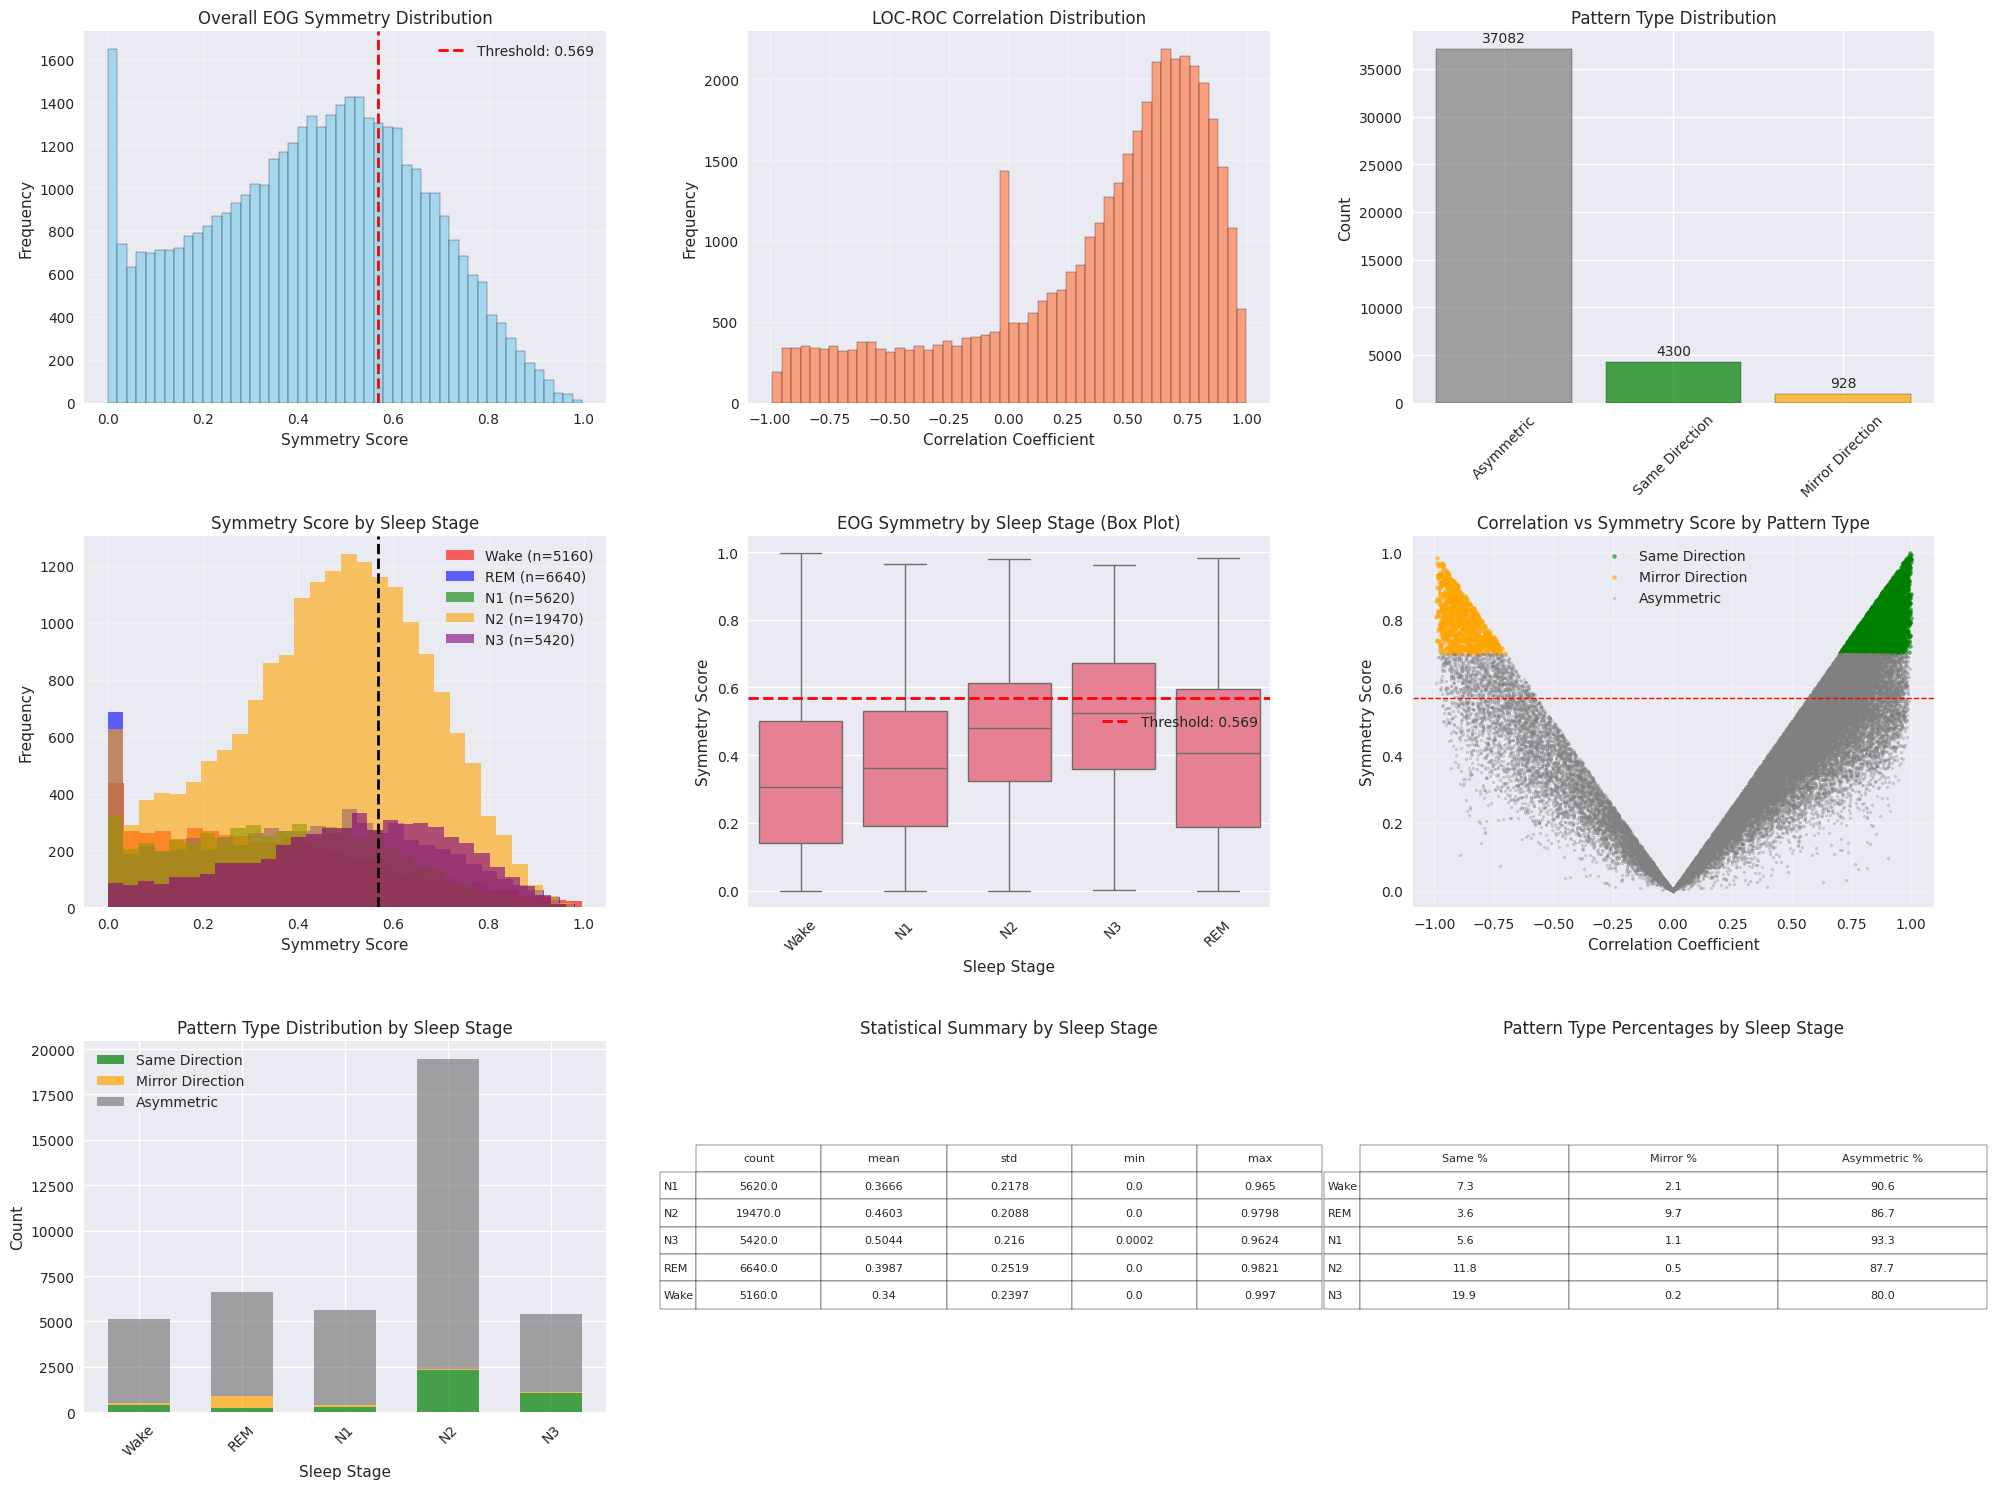


Detailed Statistics by Sleep Stage:
            count    mean     std     min     max
stage_name                                       
N1           5620  0.3666  0.2178  0.0000  0.9650
N2          19470  0.4603  0.2088  0.0000  0.9798
N3           5420  0.5044  0.2160  0.0002  0.9624
REM          6640  0.3987  0.2519  0.0000  0.9821
Wake         5160  0.3400  0.2397  0.0000  0.9970


In [53]:
# Statistical Analysis and Visualization
sleep_stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

# Create DataFrame for analysis
df = pd.DataFrame({
    'symmetry_score': all_symmetry_scores,
    'correlation': all_correlation_values,
    'pattern_type': all_pattern_types,
    'sleep_stage': all_sleep_stages,
    'stage_name': [sleep_stage_names[int(stage)] for stage in all_sleep_stages]
})

# Overall symmetry distribution
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Overall symmetry histogram
axes[0, 0].hist(all_symmetry_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(symmetry_threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Threshold: {symmetry_threshold:.3f}')
axes[0, 0].set_xlabel('Symmetry Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall EOG Symmetry Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Correlation distribution
axes[0, 1].hist(all_correlation_values, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Correlation Coefficient')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('LOC-ROC Correlation Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Pattern type distribution
pattern_labels = ['Asymmetric', 'Same Direction', 'Mirror Direction']
pattern_counts = [np.sum(all_pattern_types == 0), np.sum(all_pattern_types == 1), np.sum(all_pattern_types == -1)]
colors = ['gray', 'green', 'orange']
axes[0, 2].bar(pattern_labels, pattern_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Pattern Type Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)
for i, count in enumerate(pattern_counts):
    axes[0, 2].text(i, count + max(pattern_counts)*0.01, str(count), ha='center', va='bottom')

# 4. Symmetry by sleep stage
stage_colors = ['red', 'blue', 'green', 'orange', 'purple']
for stage in range(5):
    stage_data = df[df['sleep_stage'] == stage]['symmetry_score']
    if len(stage_data) > 0:
        axes[1, 0].hist(stage_data, bins=30, alpha=0.6, 
                       label=f'{sleep_stage_names[stage]} (n={len(stage_data)})',
                       color=stage_colors[stage])

axes[1, 0].axvline(symmetry_threshold, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Symmetry Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Symmetry Score by Sleep Stage')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Box plot by sleep stage
sns.boxplot(data=df, x='stage_name', y='symmetry_score', ax=axes[1, 1])
axes[1, 1].axhline(symmetry_threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Threshold: {symmetry_threshold:.3f}')
axes[1, 1].set_xlabel('Sleep Stage')
axes[1, 1].set_ylabel('Symmetry Score')
axes[1, 1].set_title('EOG Symmetry by Sleep Stage (Box Plot)')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Scatter plot: Correlation vs Symmetry (colored by pattern type)
same_mask = all_pattern_types == 1
mirror_mask = all_pattern_types == -1
asymmetric_mask = all_pattern_types == 0

axes[1, 2].scatter(all_correlation_values[same_mask], all_symmetry_scores[same_mask], 
                  c='green', alpha=0.6, s=8, label='Same Direction')
axes[1, 2].scatter(all_correlation_values[mirror_mask], all_symmetry_scores[mirror_mask], 
                  c='orange', alpha=0.6, s=8, label='Mirror Direction')
axes[1, 2].scatter(all_correlation_values[asymmetric_mask], all_symmetry_scores[asymmetric_mask], 
                  c='gray', alpha=0.3, s=4, label='Asymmetric')
axes[1, 2].axhline(symmetry_threshold, color='red', linestyle='--', linewidth=1)
axes[1, 2].set_xlabel('Correlation Coefficient')
axes[1, 2].set_ylabel('Symmetry Score')
axes[1, 2].set_title('Correlation vs Symmetry Score by Pattern Type')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# 7. Pattern type by sleep stage (stacked bar)
pattern_by_stage = {}
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        same_count = np.sum((all_pattern_types == 1) & stage_mask)
        mirror_count = np.sum((all_pattern_types == -1) & stage_mask)
        asymmetric_count = np.sum((all_pattern_types == 0) & stage_mask)
        pattern_by_stage[sleep_stage_names[stage]] = [same_count, mirror_count, asymmetric_count]

if pattern_by_stage:
    stages = list(pattern_by_stage.keys())
    same_counts = [pattern_by_stage[stage][0] for stage in stages]
    mirror_counts = [pattern_by_stage[stage][1] for stage in stages]
    asymmetric_counts = [pattern_by_stage[stage][2] for stage in stages]
    
    x_pos = np.arange(len(stages))
    width = 0.6
    
    axes[2, 0].bar(x_pos, same_counts, width, label='Same Direction', color='green', alpha=0.7)
    axes[2, 0].bar(x_pos, mirror_counts, width, bottom=same_counts, label='Mirror Direction', color='orange', alpha=0.7)
    axes[2, 0].bar(x_pos, asymmetric_counts, width, 
                  bottom=np.array(same_counts) + np.array(mirror_counts), 
                  label='Asymmetric', color='gray', alpha=0.7)
    
    axes[2, 0].set_xlabel('Sleep Stage')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_title('Pattern Type Distribution by Sleep Stage')
    axes[2, 0].set_xticks(x_pos)
    axes[2, 0].set_xticklabels(stages, rotation=45)
    axes[2, 0].legend()

# 8. Statistical summary table
stats_summary = df.groupby('stage_name')['symmetry_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
axes[2, 1].axis('tight')
axes[2, 1].axis('off')
table = axes[2, 1].table(cellText=stats_summary.values, 
                        rowLabels=stats_summary.index,
                        colLabels=stats_summary.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)
axes[2, 1].set_title('Statistical Summary by Sleep Stage')

# 9. Pattern type percentages by sleep stage
pattern_pct_data = []
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        total = np.sum(stage_mask)
        same_pct = np.sum((all_pattern_types == 1) & stage_mask) / total * 100
        mirror_pct = np.sum((all_pattern_types == -1) & stage_mask) / total * 100
        asymmetric_pct = np.sum((all_pattern_types == 0) & stage_mask) / total * 100
        pattern_pct_data.append([sleep_stage_names[stage], same_pct, mirror_pct, asymmetric_pct])

if pattern_pct_data:
    pct_df = pd.DataFrame(pattern_pct_data, columns=['Stage', 'Same %', 'Mirror %', 'Asymmetric %'])
    axes[2, 2].axis('tight')
    axes[2, 2].axis('off')
    pct_table = axes[2, 2].table(cellText=pct_df.iloc[:, 1:].round(1).values,
                                rowLabels=pct_df['Stage'],
                                colLabels=pct_df.columns[1:],
                                cellLoc='center', loc='center')
    pct_table.auto_set_font_size(False)
    pct_table.set_fontsize(8)
    pct_table.scale(1.2, 1.5)
    axes[2, 2].set_title('Pattern Type Percentages by Sleep Stage')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDetailed Statistics by Sleep Stage:")
print(stats_summary)

In [54]:
# Classify all windows for symmetric EOG with pattern type distinction
symmetric_classifications = all_symmetry_scores > symmetry_threshold

# Calculate percentages for all patterns
total_windows = len(all_symmetry_scores)
symmetric_count = np.sum(symmetric_classifications)
same_count = np.sum(all_pattern_types == 1)
mirror_count = np.sum(all_pattern_types == -1)
asymmetric_count = np.sum(all_pattern_types == 0)

symmetric_percentage = (symmetric_count / total_windows) * 100
same_percentage = (same_count / total_windows) * 100
mirror_percentage = (mirror_count / total_windows) * 100
asymmetric_percentage = (asymmetric_count / total_windows) * 100

print(f"\nSymmetric EOG Detection Results:")
print(f"Total 3-second windows: {total_windows}")
print(f"Symmetric EOG windows (total): {symmetric_count} ({symmetric_percentage:.1f}%)")
print(f"  - Same-direction (conjugate): {same_count} ({same_percentage:.1f}%)")
print(f"  - Mirror-direction (opposite): {mirror_count} ({mirror_percentage:.1f}%)")
print(f"Asymmetric EOG windows: {asymmetric_count} ({asymmetric_percentage:.1f}%)")

# Breakdown by sleep stage
print(f"\nSymmetric EOG by Sleep Stage:")
print(f"{'Stage':<8} {'Same':<8} {'Mirror':<8} {'Total Sym':<10} {'Asymmetric':<12} {'Total':<8}")
print("-" * 65)
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        stage_total = np.sum(stage_mask)
        stage_same = np.sum((all_pattern_types == 1) & stage_mask)
        stage_mirror = np.sum((all_pattern_types == -1) & stage_mask)
        stage_symmetric = stage_same + stage_mirror
        stage_asymmetric = np.sum((all_pattern_types == 0) & stage_mask)
        
        same_pct = (stage_same / stage_total) * 100 if stage_total > 0 else 0
        mirror_pct = (stage_mirror / stage_total) * 100 if stage_total > 0 else 0
        symmetric_pct = (stage_symmetric / stage_total) * 100 if stage_total > 0 else 0
        
        print(f"{sleep_stage_names[stage]:<8} {stage_same:<3}({same_pct:4.1f}%) {stage_mirror:<3}({mirror_pct:4.1f}%) "
              f"{stage_symmetric:<3}({symmetric_pct:5.1f}%) {stage_asymmetric:<12} {stage_total:<8}")


Symmetric EOG Detection Results:
Total 3-second windows: 42310
Symmetric EOG windows (total): 12693 (30.0%)
  - Same-direction (conjugate): 4300 (10.2%)
  - Mirror-direction (opposite): 928 (2.2%)
Asymmetric EOG windows: 37082 (87.6%)

Symmetric EOG by Sleep Stage:
Stage    Same     Mirror   Total Sym  Asymmetric   Total   
-----------------------------------------------------------------
Wake     376( 7.3%) 110( 2.1%) 486(  9.4%) 4674         5160    
REM      236( 3.6%) 645( 9.7%) 881( 13.3%) 5759         6640    
N1       314( 5.6%) 63 ( 1.1%) 377(  6.7%) 5243         5620    
N2       2298(11.8%) 100( 0.5%) 2398( 12.3%) 17072        19470   
N3       1076(19.9%) 10 ( 0.2%) 1086( 20.0%) 4334         5420    


In [55]:
# Visualization of 30-second epochs with symmetric EOG patterns
def plot_epoch_with_symmetry(loc_data, roc_data, symmetry_scores, correlation_vals, 
                             classifications, pattern_types, epoch_idx, sleep_stage, threshold):
    """
    Plot 30-second epoch with symmetric EOG analysis including pattern type distinction
    """
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    # Time axis
    time_axis = np.arange(len(loc_data)) / fs
    
    # 1. LOC signal
    axes[0].plot(time_axis, loc_data, 'b-', linewidth=0.8, label='LOC')
    axes[0].set_ylabel('LOC Amplitude')
    axes[0].set_title(f'Epoch {epoch_idx + 1}: {sleep_stage_names[int(sleep_stage)]} Stage - Left EOG (LOC)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # 2. ROC signal
    axes[1].plot(time_axis, roc_data, 'r-', linewidth=0.8, label='ROC')
    axes[1].set_ylabel('ROC Amplitude')
    axes[1].set_title('Right EOG (ROC)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Add vertical lines and color backgrounds for both EOG plots
    for ax in [axes[0], axes[1]]:
        for i in range(1, 10):
            ax.axvline(i * 3, color='gray', linestyle=':', alpha=0.5)
        
        legend_added = {'same': False, 'mirror': False, 'asymmetric': False}
        for i in range(10):
            start_time = i * 3
            end_time = (i + 1) * 3
            if classifications[i]:
                if pattern_types[i] == 1:  # Same direction
                    color, alpha, label = 'green', 0.2, 'Same Direction'
                    label = label if not legend_added['same'] else ""
                    legend_added['same'] = True
                elif pattern_types[i] == -1:  # Mirror direction
                    color, alpha, label = 'orange', 0.2, 'Mirror Direction'
                    label = label if not legend_added['mirror'] else ""
                    legend_added['mirror'] = True
                else:
                    color, alpha, label = 'gray', 0.1, ""
                ax.axvspan(start_time, end_time, alpha=alpha, color=color, label=label)
            else:
                if not legend_added['asymmetric']:
                    ax.axvspan(start_time, end_time, alpha=0.1, color='gray', label='Asymmetric')
                    legend_added['asymmetric'] = True
                else:
                    ax.axvspan(start_time, end_time, alpha=0.1, color='gray')
    
    # Add legends
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')
    
    # 3. Symmetry scores and correlation with pattern type coloring
    window_times = np.arange(10) * 3 + 1.5  # Center of each 3-second window
    
    # Plot symmetry scores as bars with pattern type colors
    colors = []
    for i in range(10):
        if classifications[i]:
            if pattern_types[i] == 1:  # Same direction
                colors.append('green')
            elif pattern_types[i] == -1:  # Mirror direction
                colors.append('orange')
            else:
                colors.append('gray')
        else:
            colors.append('gray')
    
    bars = axes[2].bar(window_times, symmetry_scores, width=2.5, color=colors, 
                      alpha=0.7, edgecolor='black')
    
    # Overlay correlation values as line plot
    ax2_twin = axes[2].twinx()
    ax2_twin.plot(window_times, correlation_vals, 'ko-', linewidth=2, 
                 markersize=6, label='Correlation', alpha=0.8)
    ax2_twin.set_ylabel('Correlation Coefficient', color='black')
    ax2_twin.tick_params(axis='y', labelcolor='black')
    ax2_twin.set_ylim(-1.1, 1.1)
    
    axes[2].axhline(threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Threshold: {threshold:.3f}')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_ylabel('Symmetry Score', color='blue')
    axes[2].tick_params(axis='y', labelcolor='blue')
    axes[2].set_title('Symmetry Analysis (Green=Same, Orange=Mirror, Gray=Asymmetric)')
    axes[2].set_xlim(0, 30)
    axes[2].legend(loc='upper left')
    ax2_twin.legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # Add values as text on bars with pattern type indicators
    for i, (bar, score, pattern_type) in enumerate(zip(bars, symmetry_scores, pattern_types)):
        height = bar.get_height()
        pattern_symbol = 'S' if pattern_type == 1 else 'M' if pattern_type == -1 else 'A'
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.2f}\\n({pattern_symbol})', ha='center', va='bottom', fontsize=7)
    
    # 4. Combined signals overlay for visual comparison
    axes[3].plot(time_axis, loc_data, 'b-', linewidth=0.8, alpha=0.7, label='LOC')
    axes[3].plot(time_axis, roc_data, 'r-', linewidth=0.8, alpha=0.7, label='ROC')
    axes[3].set_xlabel('Time (seconds)')
    axes[3].set_ylabel('Amplitude')
    axes[3].set_title('EOG Signals Overlay')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # Color background for symmetric periods with pattern type distinction
    for i in range(10):
        if classifications[i]:
            if pattern_types[i] == 1:  # Same direction
                axes[3].axvspan(i * 3, (i + 1) * 3, alpha=0.2, color='green')
            elif pattern_types[i] == -1:  # Mirror direction
                axes[3].axvspan(i * 3, (i + 1) * 3, alpha=0.2, color='orange')
    
    plt.tight_layout()
    plt.show()

# Select epochs with high symmetry for visualization (same as before)
# Find epochs with varying levels of symmetry
epoch_symmetry_means = []
for epoch_idx in range(len(all_loc_data)):
    epoch_scores = all_symmetry_scores[epoch_idx * 10:(epoch_idx + 1) * 10]
    epoch_symmetry_means.append(np.mean(epoch_scores))

epoch_symmetry_means = np.array(epoch_symmetry_means)

# Select 5 representative epochs: high, medium, and low symmetry
high_sym_indices = np.where(epoch_symmetry_means > np.percentile(epoch_symmetry_means, 80))[0]
med_sym_indices = np.where((epoch_symmetry_means > np.percentile(epoch_symmetry_means, 40)) & 
                           (epoch_symmetry_means < np.percentile(epoch_symmetry_means, 60)))[0]
low_sym_indices = np.where(epoch_symmetry_means < np.percentile(epoch_symmetry_means, 20))[0]

selected_epochs = []
if len(high_sym_indices) > 0:
    selected_epochs.append(high_sym_indices[0])
if len(high_sym_indices) > 1:
    selected_epochs.append(high_sym_indices[1])
if len(med_sym_indices) > 0:
    selected_epochs.append(med_sym_indices[0])
if len(low_sym_indices) > 0:
    selected_epochs.append(low_sym_indices[0])
if len(med_sym_indices) > 1:
    selected_epochs.append(med_sym_indices[1])

selected_epochs = selected_epochs[:5]  # Limit to 5 epochs

print(f"Selected {len(selected_epochs)} epochs for visualization")
print(f"Epoch indices: {selected_epochs}")
print("Mean symmetry scores:", end=' ')
for idx in selected_epochs:
    print(f"{epoch_symmetry_means[idx]:.3f}", end=' ')
print()  # New line

Selected 5 epochs for visualization
Epoch indices: [11, 13, 2, 0, 16]
Mean symmetry scores: 0.562 0.577 0.423 0.268 0.452 


In [56]:
# Generate XML output for each individual file with separate SYM_SAME and SYM_MIRROR events
print("\n" + "="*60)
print("GENERATING XML OUTPUT FOR SYMMETRIC EOG EVENTS")
print("="*60)

if dataset_type == "CND":
    sleep_xml_dir = "/home/honeynaps/data/250718_CND/EBX/SLEEP"
elif dataset_type == "GOLDEN":
    sleep_xml_dir = "/home/honeynaps/data/GOLDEN/EBX2/SLEEP"
else:
    raise ValueError("Invalid dataset type. Choose 'CND' or 'GOLDEN'")

print(f"Using SLEEP XML directory: {sleep_xml_dir}")

# Save XML output directory
xml_output_dir = "/home/honeynaps/data/shared/integrate/output"
os.makedirs(xml_output_dir, exist_ok=True)

# Process each file separately
file_results = {}
for file_idx in range(len(file_names[:5])):
    current_file_name = file_names[file_idx]
    base_name = current_file_name.replace('.pickle', '')
    
    # Find the corresponding SLEEP XML file
    sleep_xml_filename = f"{base_name}_SLEEP.xml"
    sleep_xml_path = os.path.join(sleep_xml_dir, sleep_xml_filename)
    
    # Check if SLEEP XML exists
    if not os.path.exists(sleep_xml_path):
        print(f"Warning: SLEEP XML not found for {current_file_name}: {sleep_xml_path}")
        print(f"  Skipping this file...")
        continue
    
    # Load the actual onset time from SLEEP XML
    try:
        meas_date = load_sleep_stage_xml(sleep_xml_path)
        print(f"  Loaded onset time from SLEEP XML: {meas_date}")
    except Exception as e:
        print(f"Error loading SLEEP XML for {current_file_name}: {e}")
        continue
    
    # Collect epochs for this file
    file_epochs_loc = []
    file_epochs_roc = []
    file_epoch_indices = []
    
    for epoch_idx, mapping in enumerate(file_data_mapping):
        if mapping['file_idx'] == file_idx:
            file_epochs_loc.append(all_loc_data[epoch_idx])
            file_epochs_roc.append(all_roc_data[epoch_idx])
            file_epoch_indices.append(epoch_idx)
    
    if len(file_epochs_loc) == 0:
        print(f"No epochs found for file: {current_file_name}")
        continue
    
    print(f"\nProcessing file {file_idx + 1}/5: {current_file_name}")
    print(f"  Number of epochs: {len(file_epochs_loc)}")
    
    # Create continuous labels for this file
    file_epoch_labels_same = []
    file_epoch_labels_mirror = []
    
    for loc_data, roc_data in zip(file_epochs_loc, file_epochs_roc):
        # Detect symmetric patterns with pattern types
        symmetric_windows, symmetry_scores, _, pattern_types = detect_symmetric_patterns(
            loc_data, roc_data, window_size, threshold=symmetry_threshold
        )
        
        # Create continuous labels for this epoch
        epoch_labels_same, epoch_labels_mirror = create_symmetric_labels(
            symmetric_windows, pattern_types, fs, window_size
        )
        file_epoch_labels_same.append(epoch_labels_same)
        file_epoch_labels_mirror.append(epoch_labels_mirror)
    
    # Concatenate all epoch labels for this file
    y_same_continuous_file = np.concatenate(file_epoch_labels_same)
    y_mirror_continuous_file = np.concatenate(file_epoch_labels_mirror)
    
    # Generate XML filename for this file
    xml_filename = f"{base_name}_EOG_SYM.xml"
    xml_save_path = os.path.join(xml_output_dir, xml_filename)
    
    # Save XML with symmetric EOG events for this file
    event_count_same, event_count_mirror = save_symmetric_eog_xml(
        meas_date=meas_date,  # Use actual onset time from SLEEP XML
        y_same_epochs=y_same_continuous_file,
        y_mirror_epochs=y_mirror_continuous_file,
        sfreq=fs,
        xml_save_path=xml_save_path,
        min_duration=1.0  # Minimum 1 second events
    )
    
    # Calculate statistics for this file
    total_samples = len(y_same_continuous_file)
    same_samples = np.sum(y_same_continuous_file)
    mirror_samples = np.sum(y_mirror_continuous_file)
    total_symmetric_samples = same_samples + mirror_samples
    
    same_percentage = (same_samples / total_samples * 100) if total_samples > 0 else 0
    mirror_percentage = (mirror_samples / total_samples * 100) if total_samples > 0 else 0
    total_symmetric_percentage = (total_symmetric_samples / total_samples * 100) if total_samples > 0 else 0
    
    file_results[current_file_name] = {
        'xml_path': xml_save_path,
        'event_count_same': event_count_same,
        'event_count_mirror': event_count_mirror,
        'event_count_total': event_count_same + event_count_mirror,
        'total_seconds': total_samples / fs,
        'same_seconds': same_samples / fs,
        'mirror_seconds': mirror_samples / fs,
        'total_symmetric_seconds': total_symmetric_samples / fs,
        'same_percentage': same_percentage,
        'mirror_percentage': mirror_percentage,
        'total_symmetric_percentage': total_symmetric_percentage
    }
    
    print(f"  XML saved: {xml_filename}")
    print(f"  Events detected:")
    print(f"    - SYM_SAME: {event_count_same} events ({same_samples/fs:.1f}s, {same_percentage:.1f}%)")
    print(f"    - SYM_MIRROR: {event_count_mirror} events ({mirror_samples/fs:.1f}s, {mirror_percentage:.1f}%)")
    print(f"    - Total symmetric: {event_count_same + event_count_mirror} events ({total_symmetric_samples/fs:.1f}s, {total_symmetric_percentage:.1f}%)")
    print(f"  Total duration: {total_samples/fs:.1f} seconds")

# Summary of all files
print("\n" + "="*60)
print("SUMMARY OF ALL FILES")
print("="*60)

if file_results:
    print(f"\n{'File Name':<40} {'Same':<8} {'Mirror':<8} {'Total':<8} {'Same(s)':<10} {'Mirror(s)':<10} {'Total(s)':<10} {'Same%':<6} {'Mirror%':<7} {'Total%':<6}")
    print("-" * 120)

    for file_name, results in file_results.items():
        print(f"{file_name[:38]:<40} {results['event_count_same']:<8} {results['event_count_mirror']:<8} "
              f"{results['event_count_total']:<8} {results['same_seconds']:<10.1f} {results['mirror_seconds']:<10.1f} "
              f"{results['total_symmetric_seconds']:<10.1f} {results['same_percentage']:<6.1f} {results['mirror_percentage']:<7.1f} "
              f"{results['total_symmetric_percentage']:<6.1f}")

    # Calculate overall statistics
    total_same_events = sum(r['event_count_same'] for r in file_results.values())
    total_mirror_events = sum(r['event_count_mirror'] for r in file_results.values())
    total_all_events = sum(r['event_count_total'] for r in file_results.values())
    total_duration = sum(r['total_seconds'] for r in file_results.values())
    total_same_duration = sum(r['same_seconds'] for r in file_results.values())
    total_mirror_duration = sum(r['mirror_seconds'] for r in file_results.values())
    total_symmetric_duration = sum(r['total_symmetric_seconds'] for r in file_results.values())

    overall_same_pct = (total_same_duration / total_duration * 100) if total_duration > 0 else 0
    overall_mirror_pct = (total_mirror_duration / total_duration * 100) if total_duration > 0 else 0
    overall_symmetric_pct = (total_symmetric_duration / total_duration * 100) if total_duration > 0 else 0

    print("-" * 120)
    print(f"{'OVERALL':<40} {total_same_events:<8} {total_mirror_events:<8} "
          f"{total_all_events:<8} {total_same_duration:<10.1f} {total_mirror_duration:<10.1f} "
          f"{total_symmetric_duration:<10.1f} {overall_same_pct:<6.1f} {overall_mirror_pct:<7.1f} "
          f"{overall_symmetric_pct:<6.1f}")

    print("\n" + "="*60)
    print(f"XML files saved to: {xml_output_dir}")
    print(f"Total files processed: {len(file_results)}")
    print(f"Threshold used: {symmetry_threshold:.4f} ({threshold_percentile}th percentile)")
    print("Event descriptions: SYM_SAME (same-direction) and SYM_MIRROR (mirror-direction)")
    print("="*60)
else:
    print("No files were successfully processed.")
    print("Please check that SLEEP XML files exist in the specified directory.")


GENERATING XML OUTPUT FOR SYMMETRIC EOG EVENTS
Using SLEEP XML directory: /home/honeynaps/data/GOLDEN/EBX2/SLEEP
  Loaded onset time from SLEEP XML: 2023-11-28 22:19:30

Processing file 1/5: SCH_F_20_OB_231128R4_NO.pickle
  Number of epochs: 892
  XML saved: SCH_F_20_OB_231128R4_NO_EOG_SYM.xml
  Events detected:
    - SYM_SAME: 1609 events (11514.0s, 43.0%)
    - SYM_MIRROR: 169 events (594.0s, 2.2%)
    - Total symmetric: 1778 events (12108.0s, 45.2%)
  Total duration: 26760.0 seconds
  Loaded onset time from SLEEP XML: 2023-07-15 22:13:00

Processing file 2/5: SCH_F_20_OV_230715R3_MO.pickle
  Number of epochs: 888
  XML saved: SCH_F_20_OV_230715R3_MO_EOG_SYM.xml
  Events detected:
    - SYM_SAME: 1135 events (6903.0s, 25.9%)
    - SYM_MIRROR: 360 events (1890.0s, 7.1%)
    - Total symmetric: 1495 events (8793.0s, 33.0%)
  Total duration: 26640.0 seconds
  Loaded onset time from SLEEP XML: 2023-05-11 22:35:30

Processing file 3/5: SCH_F_40_NW_230511R3_SE.pickle
  Number of epochs: 82


Generating epoch visualizations for symmetric EOG patterns...

Plotting Epoch 1/5 (Index: 11)


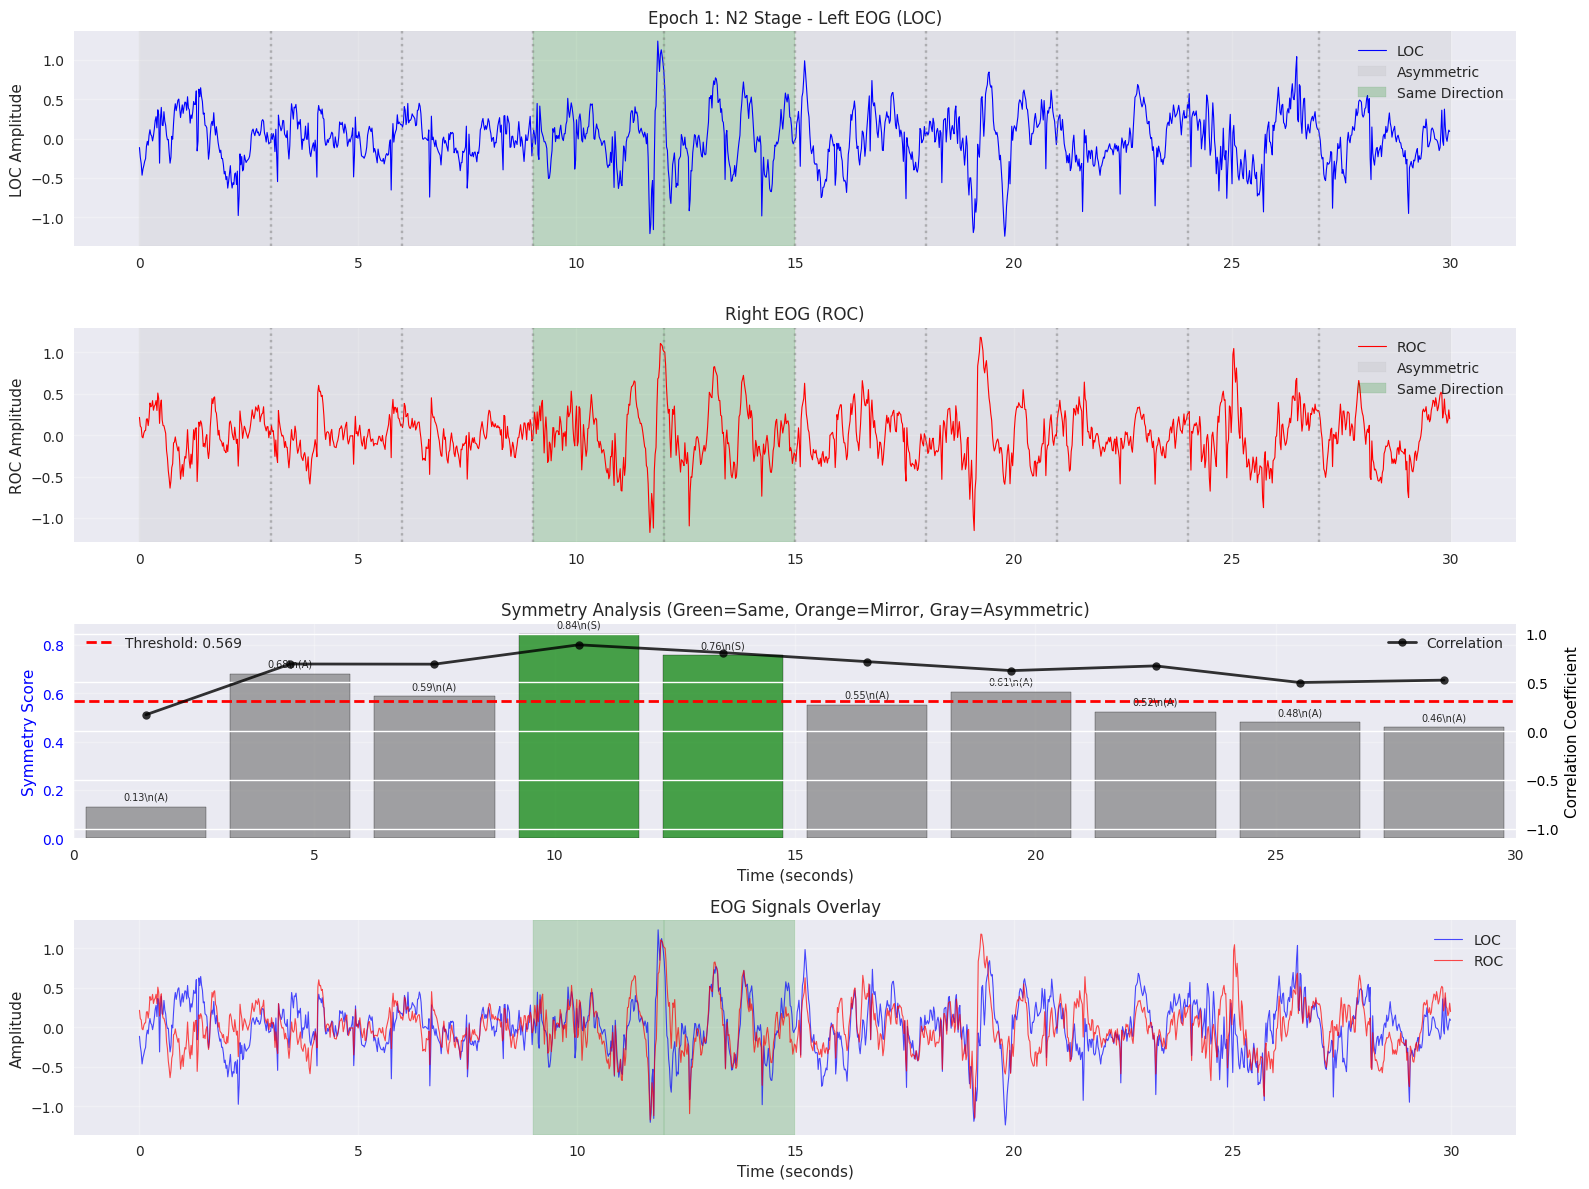

Sleep Stage: N2
Symmetric windows: 5/10
  - Same-direction: 2/10
  - Mirror-direction: 0/10
Mean symmetry score: 0.562
Mean correlation: 0.626
Mean absolute correlation: 0.626
Symmetry range: 0.132 - 0.843
--------------------------------------------------

Plotting Epoch 2/5 (Index: 13)


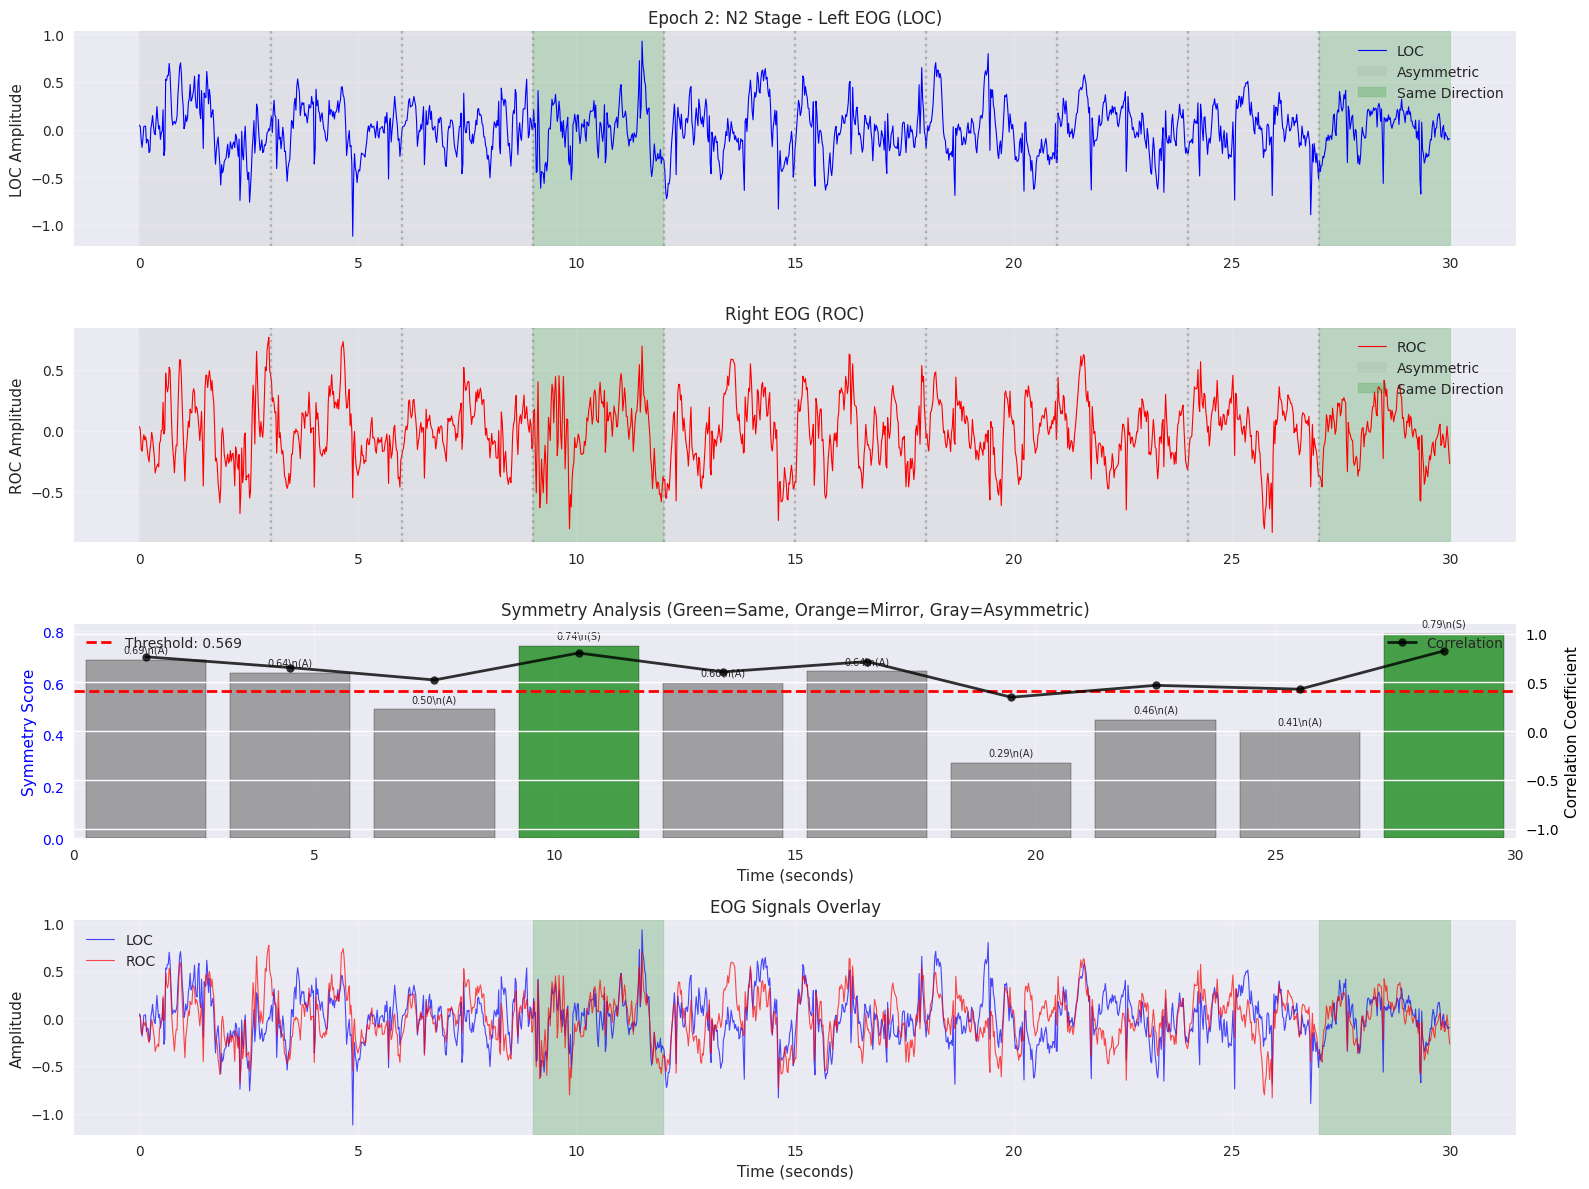

Sleep Stage: N2
Symmetric windows: 6/10
  - Same-direction: 2/10
  - Mirror-direction: 0/10
Mean symmetry score: 0.577
Mean correlation: 0.613
Mean absolute correlation: 0.613
Symmetry range: 0.292 - 0.789
--------------------------------------------------

Plotting Epoch 3/5 (Index: 2)


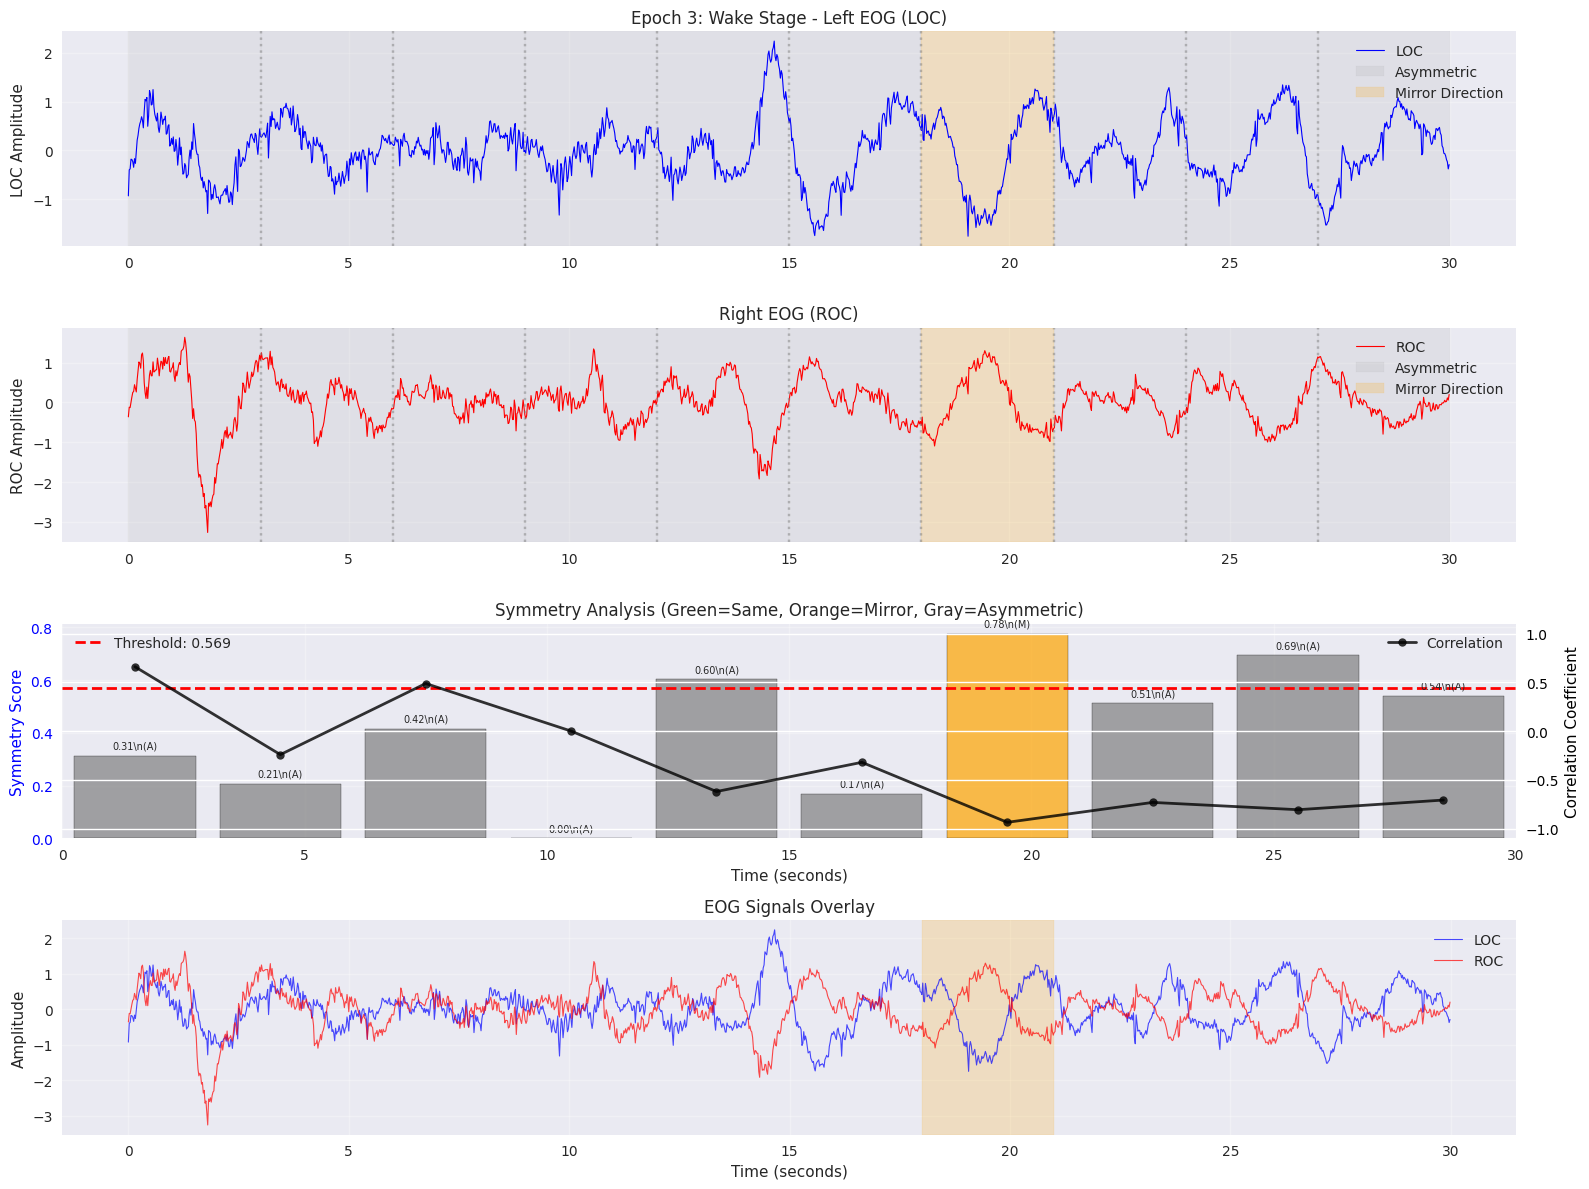

Sleep Stage: Wake
Symmetric windows: 3/10
  - Same-direction: 0/10
  - Mirror-direction: 1/10
Mean symmetry score: 0.423
Mean correlation: -0.321
Mean absolute correlation: 0.550
Symmetry range: 0.001 - 0.775
--------------------------------------------------

Plotting Epoch 4/5 (Index: 0)


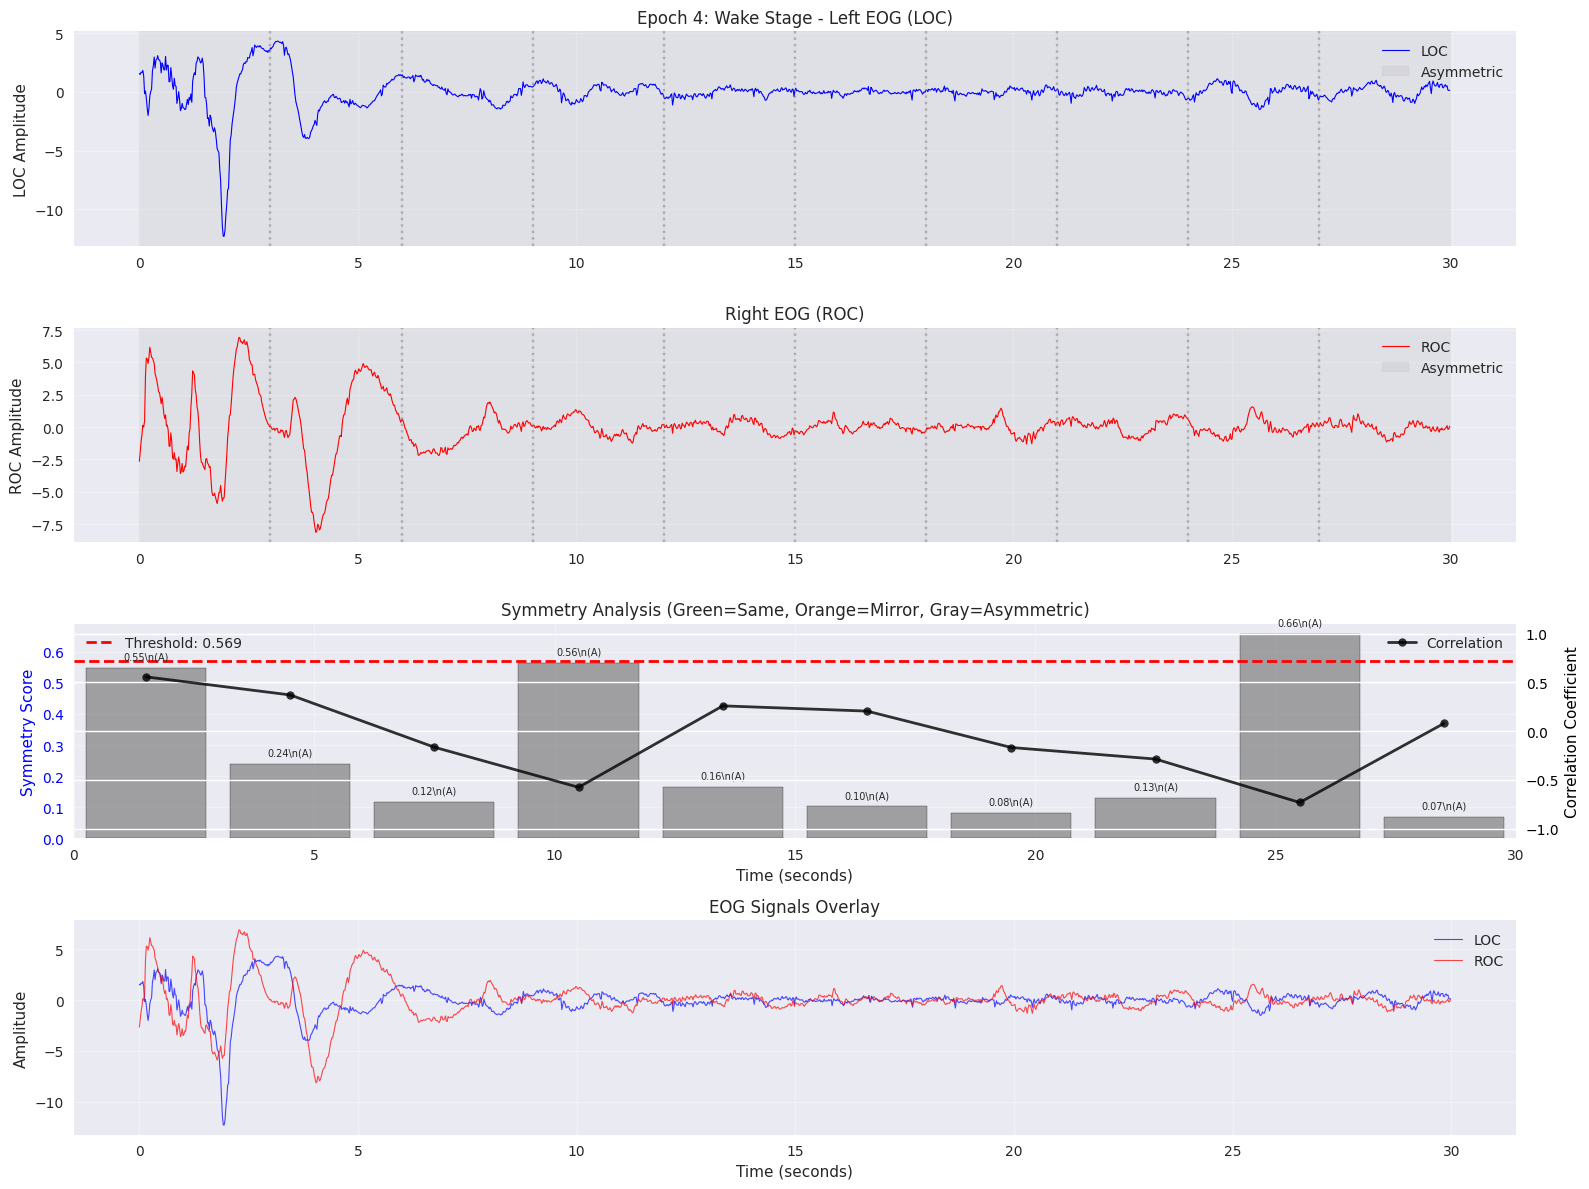

Sleep Stage: Wake
Symmetric windows: 1/10
  - Same-direction: 0/10
  - Mirror-direction: 0/10
Mean symmetry score: 0.268
Mean correlation: -0.045
Mean absolute correlation: 0.340
Symmetry range: 0.069 - 0.657
--------------------------------------------------

Plotting Epoch 5/5 (Index: 16)


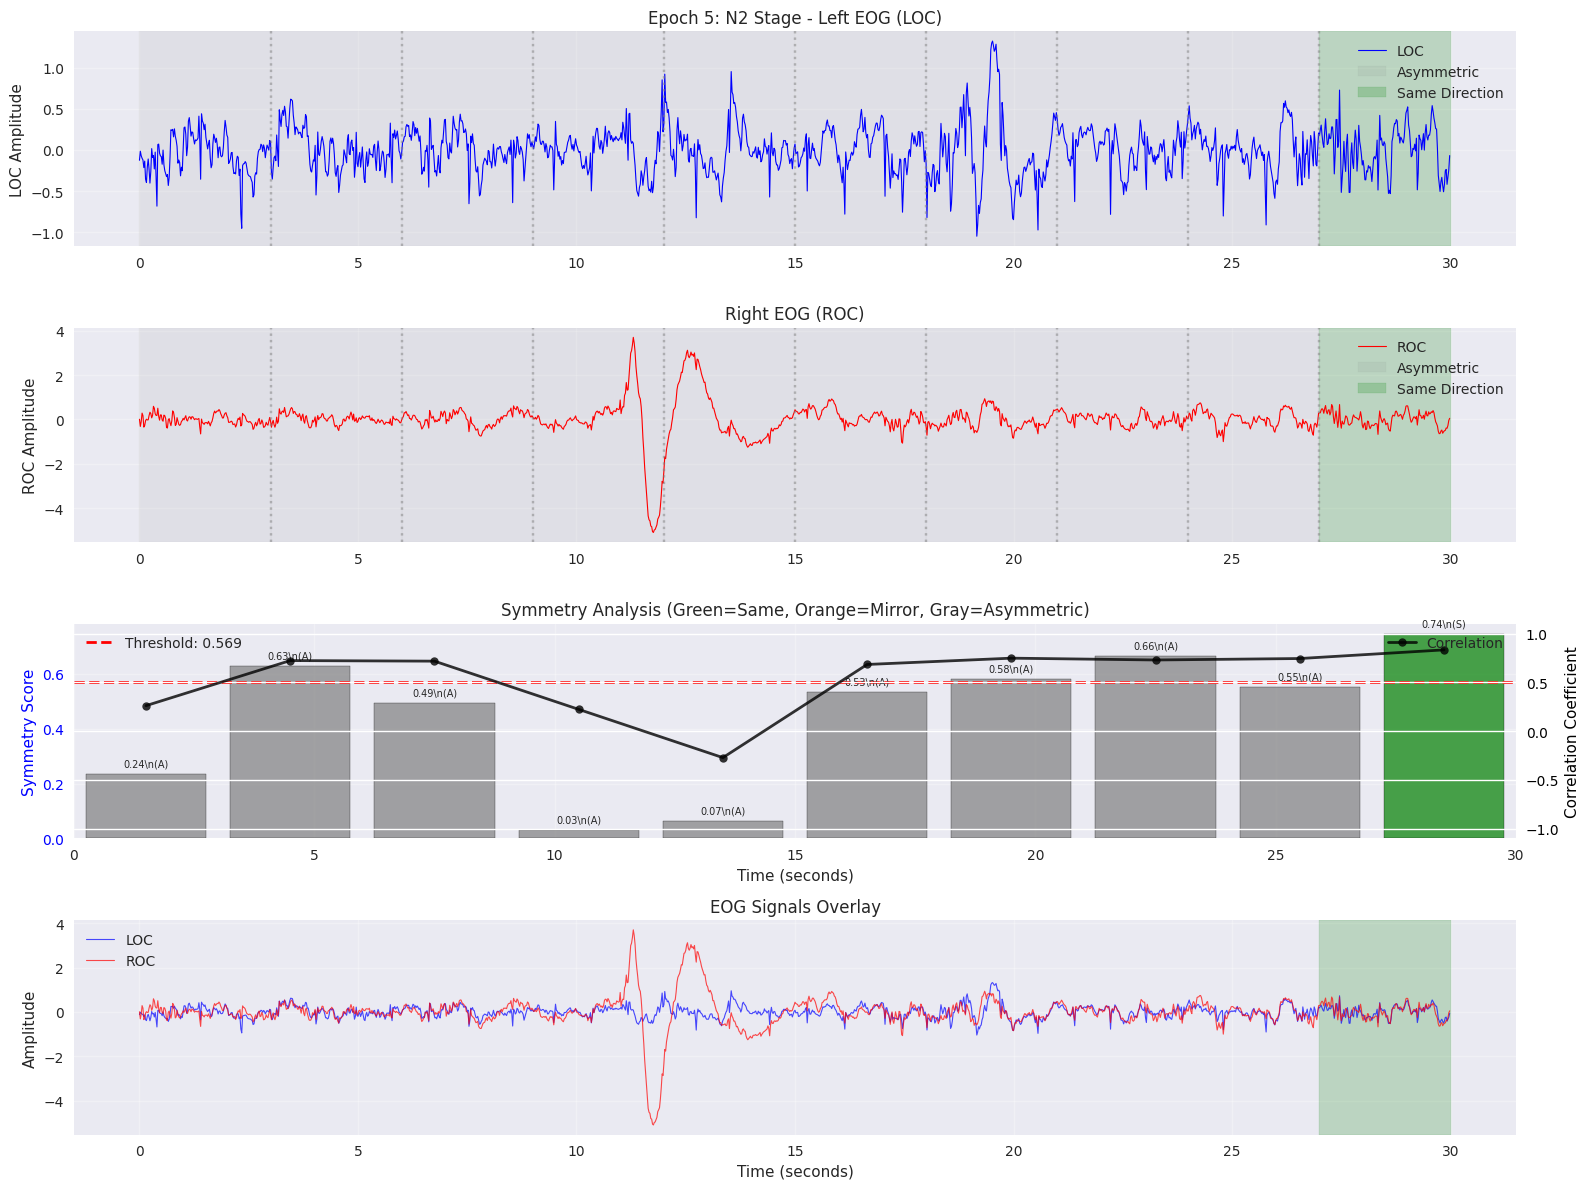

Sleep Stage: N2
Symmetric windows: 4/10
  - Same-direction: 1/10
  - Mirror-direction: 0/10
Mean symmetry score: 0.452
Mean correlation: 0.539
Mean absolute correlation: 0.594
Symmetry range: 0.030 - 0.744
--------------------------------------------------


In [57]:
# Plot the selected epochs with symmetric EOG patterns including pattern type distinction
print("\nGenerating epoch visualizations for symmetric EOG patterns...")
print("="*60)

for i, epoch_idx in enumerate(selected_epochs):
    print(f"\nPlotting Epoch {i+1}/{len(selected_epochs)} (Index: {epoch_idx})")
    
    # Get EOG data for this epoch
    epoch_loc = all_loc_data[epoch_idx]
    epoch_roc = all_roc_data[epoch_idx]
    
    # Get analysis results for this epoch
    epoch_symmetry_scores = all_symmetry_scores[epoch_idx * 10:(epoch_idx + 1) * 10]
    epoch_correlation_vals = all_correlation_values[epoch_idx * 10:(epoch_idx + 1) * 10]
    epoch_pattern_types = all_pattern_types[epoch_idx * 10:(epoch_idx + 1) * 10]
    
    # Get classifications
    epoch_classifications = epoch_symmetry_scores > symmetry_threshold
    
    # Get sleep stage
    sleep_stage = int(all_sleep_stages[epoch_idx * 10])
    
    # Plot
    plot_epoch_with_symmetry(epoch_loc, epoch_roc, epoch_symmetry_scores, 
                            epoch_correlation_vals, epoch_classifications, 
                            epoch_pattern_types, i, sleep_stage, symmetry_threshold)
    
    # Print summary for this epoch
    symmetric_count_epoch = np.sum(epoch_classifications)
    same_count_epoch = np.sum(epoch_pattern_types == 1)
    mirror_count_epoch = np.sum(epoch_pattern_types == -1)
    mean_symmetry = np.mean(epoch_symmetry_scores)
    mean_correlation = np.mean(epoch_correlation_vals)
    mean_abs_correlation = np.mean(np.abs(epoch_correlation_vals))
    
    print(f"Sleep Stage: {sleep_stage_names[sleep_stage]}")
    print(f"Symmetric windows: {symmetric_count_epoch}/10")
    print(f"  - Same-direction: {same_count_epoch}/10")
    print(f"  - Mirror-direction: {mirror_count_epoch}/10")
    print(f"Mean symmetry score: {mean_symmetry:.3f}")
    print(f"Mean correlation: {mean_correlation:.3f}")
    print(f"Mean absolute correlation: {mean_abs_correlation:.3f}")
    print(f"Symmetry range: {np.min(epoch_symmetry_scores):.3f} - {np.max(epoch_symmetry_scores):.3f}")
    print("-" * 50)

In [58]:
# Final summary and validation
print("\n" + "="*60)
print("FINAL SYMMETRIC EOG ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Information:")
print(f"  Total files processed: {len(file_names[:5])}")
print(f"  Total 30-second epochs: {len(all_loc_data)}")
print(f"  Total 3-second windows: {len(all_symmetry_scores)}")

print(f"\nSymmetry Analysis Method:")
print(f"  Channels analyzed: LOC (channel 7) and ROC (channel 8)")
print(f"  Window size: 3 seconds (150 samples at 50Hz)")
print(f"  Analysis metrics: Correlation coefficient and amplitude ratio")
print(f"  Symmetry score: |correlation| × amplitude_ratio")
print(f"  Pattern distinction: Positive correlation = Same-direction, Negative correlation = Mirror-direction")

print(f"\nThreshold Determination:")
print(f"  Method: {threshold_percentile}th percentile of symmetry scores")
print(f"  Threshold value: {symmetry_threshold:.4f}")
print(f"  Windows analyzed: {len(all_symmetry_scores)}")

print(f"\nSymmetric EOG Detection Results:")
print(f"  Total windows analyzed: {total_windows}")
print(f"  Same-direction patterns (SYM_SAME): {same_count} ({same_percentage:.1f}%)")
print(f"  Mirror-direction patterns (SYM_MIRROR): {mirror_count} ({mirror_percentage:.1f}%)")
print(f"  Total symmetric patterns: {symmetric_count} ({symmetric_percentage:.1f}%)")
print(f"  Asymmetric patterns: {asymmetric_count} ({asymmetric_percentage:.1f}%)")

print(f"\nPattern Type Distribution by Sleep Stage:")
print(f"{'Stage':<8} {'Same':<12} {'Mirror':<12} {'Total Sym':<12} {'Asymmetric':<12} {'Total':<8}")
print("-" * 75)
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        stage_total = np.sum(stage_mask)
        stage_same = np.sum((all_pattern_types == 1) & stage_mask)
        stage_mirror = np.sum((all_pattern_types == -1) & stage_mask)
        stage_symmetric = stage_same + stage_mirror
        stage_asymmetric = np.sum((all_pattern_types == 0) & stage_mask)
        
        same_pct = (stage_same / stage_total) * 100 if stage_total > 0 else 0
        mirror_pct = (stage_mirror / stage_total) * 100 if stage_total > 0 else 0
        symmetric_pct = (stage_symmetric / stage_total) * 100 if stage_total > 0 else 0
        
        print(f"{sleep_stage_names[stage]:<8} {stage_same:<4}({same_pct:5.1f}%) {stage_mirror:<4}({mirror_pct:5.1f}%) "
              f"{stage_symmetric:<4}({symmetric_pct:5.1f}%) {stage_asymmetric:<12} {stage_total:<8}")

print(f"\nCorrelation Statistics:")
print(f"  Mean correlation: {np.mean(all_correlation_values):.3f}")
print(f"  Mean absolute correlation: {np.mean(np.abs(all_correlation_values)):.3f}")
print(f"  Positive correlations (same-direction): {np.sum(all_correlation_values > 0)} windows")
print(f"  Negative correlations (mirror-direction): {np.sum(all_correlation_values < 0)} windows")
print(f"  Strong positive correlations (>0.5): {np.sum(all_correlation_values > 0.5)} windows")
print(f"  Strong negative correlations (<-0.5): {np.sum(all_correlation_values < -0.5)} windows")

print(f"\nXML Output Summary:")
print(f"  Output directory: {xml_output_dir}")
print(f"  Files generated: {len(file_results)} XML files")
print(f"  Naming format: [original_name]_EOG_SYM.xml")
print(f"  Event descriptions:")
print(f"    - SYM_SAME: Same-direction (conjugate) eye movements")
print(f"    - SYM_MIRROR: Mirror-direction (opposite) eye movements")
print(f"  Channel location: LOC-ROC")
print(f"  Minimum event duration: 1.0 seconds")

print(f"\nOverall XML Event Statistics:")
if file_results:
    total_same_events = sum(r['event_count_same'] for r in file_results.values())
    total_mirror_events = sum(r['event_count_mirror'] for r in file_results.values())
    total_all_events = sum(r['event_count_total'] for r in file_results.values())
    total_duration = sum(r['total_seconds'] for r in file_results.values())
    
    print(f"  Total SYM_SAME events: {total_same_events}")
    print(f"  Total SYM_MIRROR events: {total_mirror_events}")
    print(f"  Total symmetric events: {total_all_events}")
    print(f"  Total recording duration: {total_duration:.1f} seconds ({total_duration/3600:.1f} hours)")
    print(f"  Event density: {total_all_events/(total_duration/3600):.1f} events per hour")

print(f"\nVisualization Summary:")
print(f"  {len(selected_epochs)} representative epochs plotted")
print(f"  Each plot shows:")
print(f"    - LOC and ROC signals separately with pattern type coloring")
print(f"    - Symmetry scores and correlation values")
print(f"    - Overlay comparison of both channels")
print(f"    - Color coding: Green = Same-direction, Orange = Mirror-direction, Gray = Asymmetric")
print(f"    - Pattern symbols: S = Same, M = Mirror, A = Asymmetric")

print("\n" + "="*60)
print("Symmetric EOG analysis with pattern type distinction completed successfully!")
print("Individual XML files generated with SYM_SAME and SYM_MIRROR events for each sample!")
print("="*60)


FINAL SYMMETRIC EOG ANALYSIS SUMMARY

Dataset Information:
  Total files processed: 5
  Total 30-second epochs: 4231
  Total 3-second windows: 42310

Symmetry Analysis Method:
  Channels analyzed: LOC (channel 7) and ROC (channel 8)
  Window size: 3 seconds (150 samples at 50Hz)
  Analysis metrics: Correlation coefficient and amplitude ratio
  Symmetry score: |correlation| × amplitude_ratio
  Pattern distinction: Positive correlation = Same-direction, Negative correlation = Mirror-direction

Threshold Determination:
  Method: 70th percentile of symmetry scores
  Threshold value: 0.5687
  Windows analyzed: 42310

Symmetric EOG Detection Results:
  Total windows analyzed: 42310
  Same-direction patterns (SYM_SAME): 4300 (23.8%)
  Mirror-direction patterns (SYM_MIRROR): 928 (5.6%)
  Total symmetric patterns: 12693 (30.0%)
  Asymmetric patterns: 37082 (87.6%)

Pattern Type Distribution by Sleep Stage:
Stage    Same         Mirror       Total Sym    Asymmetric   Total   
------------------